## 🏠 Room Occupancy Prediction: Random Split vs. Time-Aware Evaluation

강의실 점유율 예측 프로젝트를 위한 데이터 분석

주어진 센서 데이터(온도, 조도, 소리, CO2, PIR)를 활용하여 강의실의 재실 인원(`Room_Occupancy_Count`)을 예측하는 모델을 개발하고, **Random Split 방식**과 **Time-Aware Evaluation 방식**으로 성능을 비교 분석

---

Data analysis for a classroom occupancy prediction project

Develop a model to predict the number of people in a classroom (`Room_Occupancy_Count`) using the provided sensor data (temperature, illuminance, sound, CO2, and PIR), and compare its performance using **Random Split** and **Time-Aware Evaluation**.


# 1. 데이터 불러오기 및 확인

---

# 1. Load and Verify Data

In [ ]:
pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 31.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/OneInsight Lab/Projects/Room Occupancy/Data/Occupancy_Estimation.csv")

In [ ]:
df.shape

(10129, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10129 non-null  object 
 1   Time                  10129 non-null  object 
 2   S1_Temp               10129 non-null  float64
 3   S2_Temp               10129 non-null  float64
 4   S3_Temp               10129 non-null  float64
 5   S4_Temp               10129 non-null  float64
 6   S1_Light              10129 non-null  int64  
 7   S2_Light              10129 non-null  int64  
 8   S3_Light              10129 non-null  int64  
 9   S4_Light              10129 non-null  int64  
 10  S1_Sound              10129 non-null  float64
 11  S2_Sound              10129 non-null  float64
 12  S3_Sound              10129 non-null  float64
 13  S4_Sound              10129 non-null  float64
 14  S5_CO2                10129 non-null  int64  
 15  S5_CO2_Slope       

In [ ]:
df.describe()

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
count,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.00000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000,10129.000000
mean,25.454012,25.546059,25.056621,25.754125,25.445059,26.01629,34.248494,13.220259,0.168178,0.120066,0.158119,0.103840,460.860401,-0.004830,0.090137,0.079574,0.398559
std,0.351351,0.586325,0.427283,0.356434,51.011264,67.30417,58.400744,19.602219,0.316709,0.266503,0.413637,0.120683,199.964940,1.164990,0.286392,0.270645,0.893633
min,24.940000,24.750000,24.440000,24.940000,0.000000,0.00000,0.000000,0.000000,0.060000,0.040000,0.040000,0.050000,345.000000,-6.296154,0.000000,0.000000,0.000000
25%,25.190000,25.190000,24.690000,25.440000,0.000000,0.00000,0.000000,0.000000,0.070000,0.050000,0.060000,0.060000,355.000000,-0.046154,0.000000,0.000000,0.000000
50%,25.380000,25.380000,24.940000,25.750000,0.000000,0.00000,0.000000,0.000000,0.080000,0.050000,0.060000,0.080000,360.000000,0.000000,0.000000,0.000000,0.000000
75%,25.630000,25.630000,25.380000,26.000000,12.000000,14.00000,50.000000,22.000000,0.080000,0.060000,0.070000,0.100000,465.000000,0.000000,0.000000,0.000000,0.000000
max,26.380000,29.000000,26.190000,26.560000,165.000000,258.00000,280.000000,74.000000,3.880000,3.440000,3.670000,3.400000,1270.000000,8.980769,1.000000,1.000000,3.000000


### 📊 1차 데이터 확인 요약

- **데이터 크기**: 총 10129개의 행과 19개의 열로 구성
- **결측치**: 모든 컬럼에 결측치가 없는 것으로 보이나, 확인 필요
- **데이터 타입**
    - `Date`와 `Time` 컬럼은 `object` 타입으로, 시간 기반 분석을 위해 `datetime` 타입으로 변환 필요

- **우측 치우침 컬럼**
    - S2_Temp, S1_Light, S2_Light, S3_Light, S4_Light, S1_Sound, S2_Sound, S3_Sound, S4_Sound, S5_CO2, S6_PIR(약함), S7_PIR(약함), Room_Occupancy_Count

- **컬럼 분포 (df.describe() 기반)**:
    - **온도 (`S_Temp`)**: 각 센서 온도 비교적 안정적 범위, 큰 편차 없이 고르게 분포
    - **조도 (`S_Light`) & 소리 (`S_Sound`)**: `min` 값 0 또는 매우 낮은 반면 `max` 값 75% 분위수(Q3)보다 훨씬 높아, 데이터 우측 치우침 분포. 활동 없을 때 0, 활동 시 높은 값 기록하는 센서 특성 때문이라고 판단됨
    - **CO2 (`S5_CO2`)**: 주로 345~465 범위 집중, 최대 1270까지 나타나 역시 우측 치우침 분포
    - **PIR (`S6_PIR`, `S7_PIR`)**: 대부분 값 0 집중, 최대 1 가짐. 움직임 감지 센서 특성상 움직임 감지될 때만 1 나타남
    - **재실 인원 (`Room_Occupancy_Count`)**: 대부분 0에 집중, 예측 모델 구축 시 불균형 데이터 고려 필요

---

### 📊 First Data Verification Summary

- **Data Size**: Consists of 10129 rows and 19 columns
- **Missing Values**: Appears that all columns have no missing values, but verification is needed
- **Data Types**
    - The `Date` and `Time` columns are of `object` type, requiring conversion to `datetime` for time-based analysis

- **Right-Skewed Columns**
    - S2_Temp, S1_Light, S2_Light, S3_Light, S4_Light, S1_Sound, S2_Sound, S3_Sound, S4_Sound, S5_CO2, S6_PIR(weak), S7_PIR(weak), Room_Occupancy_Count

- **Column Distribution (based on df.describe())**:
    - **Temperature (`S_Temp`)**: Each sensor temperature is in a relatively stable range, evenly distributed without large deviations
    - **Illuminance (`S_Light`) & Sound (`S_Sound`)**: min value is 0 or very low, while max value is much higher than the 75th percentile (Q3), indicating a right-skewed data distribution. This is judged to be due to the sensor characteristic of recording 0 when inactive and high values when active.
    - **CO2 (`S5_CO2`)**: Concentrated mainly in the 345-465 range, with values up to 1270, also showing a right-skewed distribution
    - **PIR (`S6_PIR`, `S7_PIR`)**: Most values are concentrated at 0, with a maximum of 1. Due to the nature of motion detection sensors, 1 appears only when motion is detected.
    - **Occupancy Count (`Room_Occupancy_Count`)**: Mostly concentrated at 0, requiring consideration of imbalanced data when building prediction models

# 1차 데이터 전처리

---

# First Data Preprocessing

### 1. 시간&날짜 관련

---

### 1. Time & Date Related

In [ ]:
# datetime 생성
# Create a datetime column.
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

In [ ]:
# 날짜 순 정렬
# Sort the data chronologically.
df = df.sort_values("datetime").reset_index(drop=True)

In [ ]:
# datetime을 생성해서 기존 Date와 Time은 제거
# After creating datetime, remove the original Date and Time columns.
df = df.drop(columns=["Date", "Time"])

In [ ]:
# 시간과 분 파생변수 생성
# Create derived features for hour and minute.
df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute

In [ ]:
df.head(2)

,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,datetime,hour,minute
0,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1,2017-12-22 10:49:41,10,49
1,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1,2017-12-22 10:50:12,10,50


### 2. 중복값

---

### 2. Duplicate Values

In [ ]:
# 중복값 확인
# Check for duplicate rows.
df.duplicated().sum()

np.int64(0)

=> 중복값은 없음

---

=> No duplicate values

### 3. 타겟변수

---

### 3. Target Variable

위에서 `Room_Occupancy_Count`가 불균형 상태 분포라는 것을 체크함. 얼마나 불균형인지 확인할 필요 있음

---

Above, it was checked that `Room_Occupancy_Count` has an imbalanced distribution. It is necessary to confirm the degree of imbalance.

In [ ]:
df["Room_Occupancy_Count"].value_counts(normalize=True)

,proportion
Room_Occupancy_Count,
0,0.812321
2,0.073847
3,0.068516
1,0.045315


#### **`Room_Occupancy_Count` 분포 확인**

- `Room_Occupancy_Count`가 0인 경우가 약 81.2%로 매우 높은 비중을 차지, 데이터 불균형 심각
- 예측 모델 개발 시 불균형 데이터 처리 전략 (예: 오버샘플링, 언더샘플링, 가중치 부여 등) 고려 필요

---

#### **`Room_Occupancy_Count` Distribution Check**

- Cases where `Room_Occupancy_Count` is 0 account for a very high proportion, approximately 81.2%, indicating severe data imbalance.
- When developing prediction models, strategies for handling imbalanced data (e.g., oversampling, undersampling, weighting, etc.) need to be considered.

### 4. 상관도 확인

---

### 4. Correlation Check

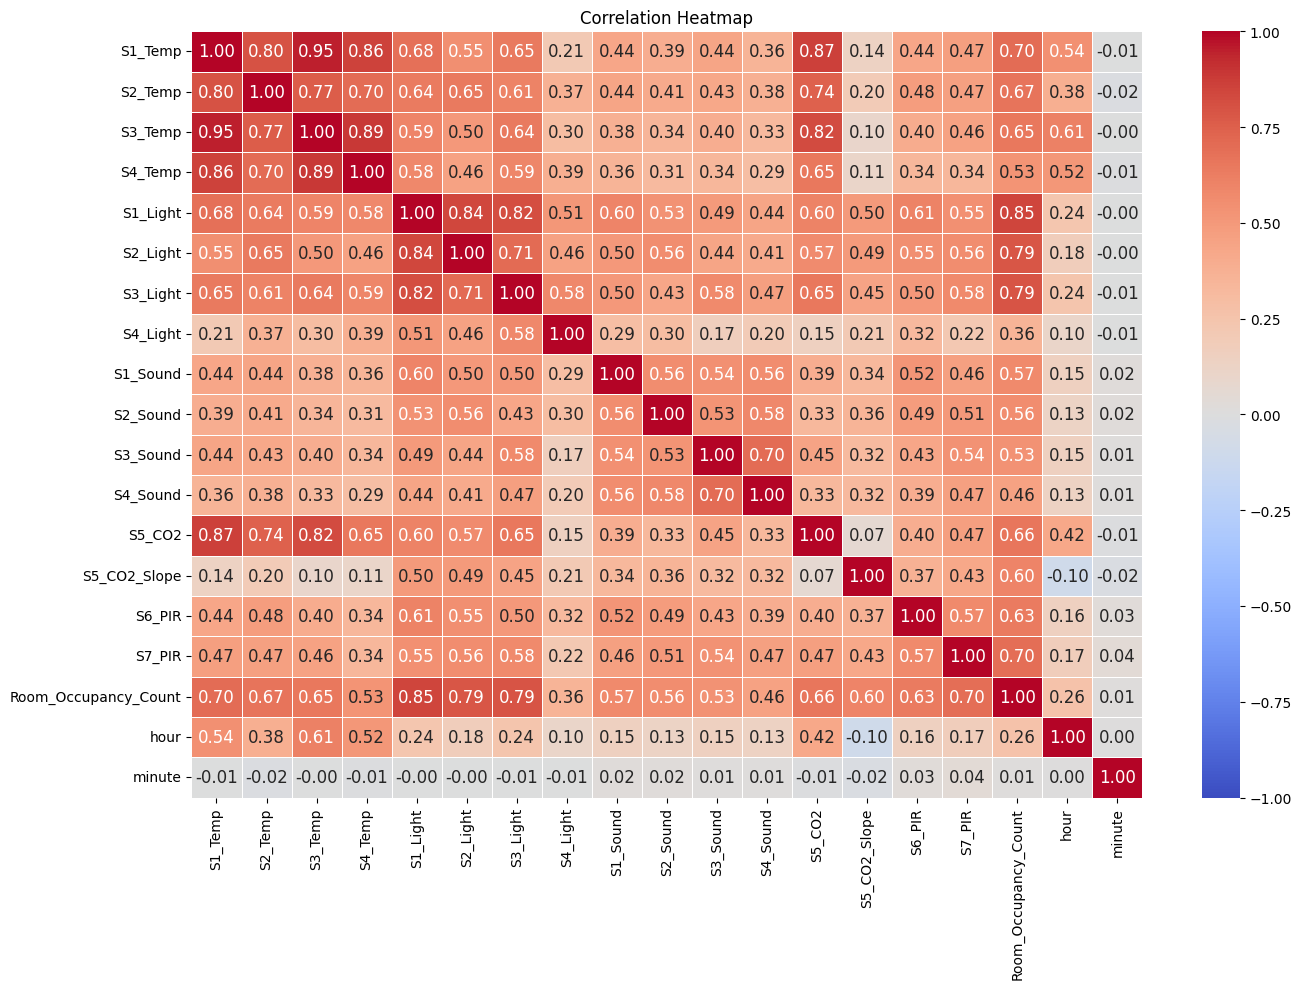

In [ ]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 12},
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# 타겟 변수와의 상관도 확인
# Check correlations with the target variable.
corr["Room_Occupancy_Count"].sort_values(ascending=False)

,Room_Occupancy_Count
Room_Occupancy_Count,1.000000
S1_Light,0.849058
S3_Light,0.793081
S2_Light,0.788764
S1_Temp,0.700868
S7_PIR,0.695138
S2_Temp,0.671263
S5_CO2,0.660144
S3_Temp,0.652047
S6_PIR,0.633133


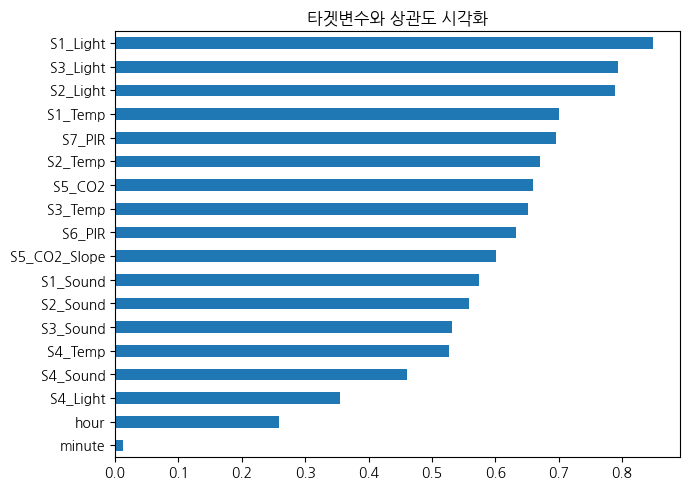

In [ ]:
# 시각화
# Visualize the results
target_corr = (
    corr["Room_Occupancy_Count"]
    .drop("Room_Occupancy_Count")
    .sort_values()
)

plt.figure(figsize=(7, 5))
target_corr.plot(kind="barh")

plt.title("타겟변수와 상관도 시각화 (Correlation Visualization with Target Variable)")
plt.tight_layout()
plt.show()

#### 📊 상관도 종합 분석

- **`Room_Occupancy_Count`(타겟 변수)와의 상관도 서머리**
    - `S1_Light` (0.85), `S3_Light` (0.79), `S2_Light` (0.79)와 가장 높은 양의 상관관계
    - `S1_Temp` (0.70), `S7_PIR` (0.70), `S2_Temp` (0.67), `S5_CO2` (0.66) 등 센서 데이터와도 높은 양의 상관관계
    - `S4_Light` (0.36)는 조도 센서 중 상대적으로 낮은 상관관계
    - `hour` (0.26) 및 `minute` (0.01)는 타겟 변수와 매우 낮은 상관관계를 보임. 시간 자체보다 시간대별 활동 패턴이 더 중요할 가능성을 시사함
- **센서 간 관계**
    - 온도(`S_Temp`) 센서들은 서로 높은 상관관계
    - 조도(`S_Light`) 센서들도 서로 높은 상관관계
    - `S5_CO2`는 온도 센서들과 높은 양의 상관관계

**=> 정리**: `Room_Occupancy_Count`는 주로 조도, 온도, CO2 센서 값과 강한 양의 상관관계를 가짐. 이는 해당 센서들이 강의실 점유 상태를 예측하는 데 중요한 특징임을 시사

---

#### 📊 Comprehensive Correlation Analysis

- **Correlation Summary with `Room_Occupancy_Count` (Target Variable)**
    - Highest positive correlation with `S1_Light` (0.85), `S3_Light` (0.79), `S2_Light` (0.79)
    - High positive correlation with sensor data such as `S1_Temp` (0.70), `S7_PIR` (0.70), `S2_Temp` (0.67), `S5_CO2` (0.66)
    - `S4_Light` (0.36) has a relatively low correlation among illuminance sensors
    - `hour` (0.26) and `minute` (0.01) show very low correlation with the target variable. This suggests that activity patterns by time of day may be more important than time itself.
- **Relationships Between Sensors**
    - Temperature (`S_Temp`) sensors have high correlations with each other
    - Illuminance (`S_Light`) sensors also have high correlations with each other
    - `S5_CO2` has a high positive correlation with temperature sensors

**=> Summary**: `Room_Occupancy_Count` has a strong positive correlation mainly with illuminance, temperature, and CO2 sensor values. This suggests that these sensors are important features for predicting classroom occupancy status.

# 모델링

---

# Modeling

`datetime`, `hour`, `minute`은 우리가 데이터를 시간순으로 정렬하고 자르는 기준으로 쓰는 컬럼

따라서 모델링 과정에선 제거하고 진행 => 순수하게 센서데이터만 가지고 타켓변수 예측

---

`datetime`, `hour`, and `minute` are columns we use as criteria for sorting and splitting data chronologically.

Therefore, these are removed during the modeling process => proceed with predicting the target variable using only sensor data.

### **1. Random split**

일반적인 모델링 방식에서 주로 쓰는 방법론

8:2로 train/test데이터 셋을 나누고, 랜덤 포레스트 모델링 적용

---

### **1. Random split**

A commonly used methodology in general modeling approaches

Split train/test datasets 8:2, then apply Random Forest modeling

In [ ]:
# 독립변수가 종속변수 분리
# Separate the independent variables (features) from the dependent variable (target).

X = df.drop(columns=["Room_Occupancy_Count", "datetime", "hour", "minute"])
y = df["Room_Occupancy_Count"]

In [ ]:
# 데이터 셋 나누기
# Split the dataset.
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y                              # stratify=y는 타겟 변수의 클래스 비율을 유지하며 분할
    # stratify=y preserves the target variable's class proportions when splitting the data.
)

In [ ]:
# 독립변수 결과 확인
# Check the shapes of the feature datasets after splitting.
print(X_train_rand.shape)
print(X_test_rand.shape)

(8103, 16)
(2026, 16)


In [ ]:
# 종속변수 결과 확인
# Check the shapes of the target datasets after splitting.
print(y_train_rand.shape)
print(y_test_rand.shape)

(8103,)
(2026,)


### **2. Chronological Split (시간 순서대로 나누기)**

시간을 기준으로 앞부분 train / 뒷부분 test

위와 동일한 모델로 다시 평가하고 Random split 결과와 비교

---

### **2. Chronological Split (Splitting in Time Order)**

Train on the earlier part / test on the later part based on time

Evaluate again with the same model as above and compare with Random Split results

In [ ]:
# 시간 순서대로 정렬된 df를 8:2로 나눔
# Split the chronologically sorted df into training and test sets at an 80:20 ratio.
split_idx = int(len(df) * 0.8)

train_time = df.iloc[:split_idx]
test_time = df.iloc[split_idx:]

In [ ]:
# 독립변수 종속변수 분리
# Separate the independent variables (features) from the dependent variable (target).

X_train_time = train_time.drop(columns=["Room_Occupancy_Count", "datetime", "hour", "minute"])
y_train_time = train_time["Room_Occupancy_Count"]

X_test_time = test_time.drop(columns=["Room_Occupancy_Count", "datetime", "hour", "minute"])
y_test_time = test_time["Room_Occupancy_Count"]

In [ ]:
# 독립변수 확인
# Check the feature datasets.
print(X_train_time.shape)
print(X_test_time.shape)

(8103, 16)
(2026, 16)


In [ ]:
# 종속변수 날짜 확인
# Check the dates for the dependent variable.
print(train_time["datetime"].min(), "~", train_time["datetime"].max())

print(test_time["datetime"].min(), "~", test_time["datetime"].max())

2017-12-22 10:49:41 ~ 2018-01-10 15:34:59
2018-01-10 15:35:30 ~ 2018-01-11 09:00:09


### 3. Baseline 모델

---

### 3. Baseline Model

**Random Split Baseline**

In [ ]:
dummy_rand = DummyClassifier(strategy="most_frequent")
dummy_rand.fit(X_train_rand, y_train_rand)

DummyClassifier(strategy='most_frequent')

In [ ]:
y_pred_dummy_rand = dummy_rand.predict(X_test_rand)

dummy_rand_acc = accuracy_score(y_test_rand, y_pred_dummy_rand)

dummy_rand_f1 = f1_score(y_test_rand, y_pred_dummy_rand, average="macro")

In [ ]:
print("Dummy - Random Split")
print("Accuracy:", dummy_rand_acc)
print("Macro F1:", dummy_rand_f1)

Dummy - Random Split
Accuracy: 0.8124383020730503
Macro F1: 0.2241285403050109


**Random Split - Random Forest**

In [ ]:
rf_rand = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_rand.fit(X_train_rand, y_train_rand)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rand = rf_rand.predict(X_test_rand)

rand_acc = accuracy_score(y_test_rand, y_pred_rand)

rand_f1 = f1_score(y_test_rand, y_pred_rand, average="macro")

In [ ]:
print("Random Split - Random Forest")
print("Accuracy:", rand_acc)
print("Macro F1:", rand_f1)

Random Split - Random Forest
Accuracy: 0.9970384995064165
Macro F1: 0.9902839629611485


In [ ]:
# 클래스별 결과 확인
# Check the results for each class.
print(
    classification_report(
        y_test_rand,
        y_pred_rand,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1646
           1       1.00      1.00      1.00        92
           2       0.97      1.00      0.98       149
           3       1.00      0.96      0.98       139

    accuracy                           1.00      2026
   macro avg       0.99      0.99      0.99      2026
weighted avg       1.00      1.00      1.00      2026



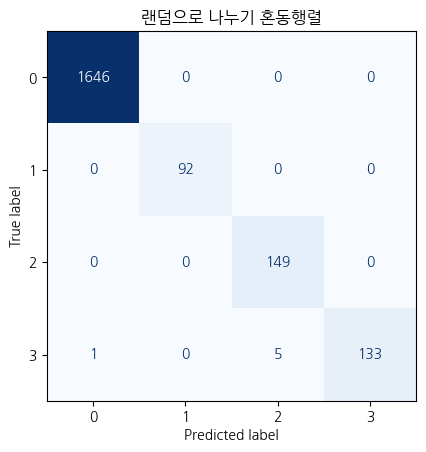

In [ ]:
# 혼동 행렬 확인
# Inspect the confusion matrix.
ConfusionMatrixDisplay.from_predictions(
    y_test_rand,
    y_pred_rand,
    cmap="Blues",
    colorbar=False
)

plt.title("랜덤으로 나누기 혼동행렬 (Random Split Confusion Matrix)")
plt.show()

**Chronological Split - Random Forest**

In [ ]:
rf_time = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_time.fit(X_train_time, y_train_time)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
y_pred_time = rf_time.predict(X_test_time)

time_acc = accuracy_score(y_test_time, y_pred_time)

time_f1 = f1_score(y_test_time, y_pred_time, average="macro")

In [ ]:
print("Chronological Split - Random Forest")
print("Accuracy:", time_acc)
print("Macro F1:", time_f1)

Chronological Split - Random Forest
Accuracy: 0.9244817374136229
Macro F1: 0.6893705225644569


In [ ]:
print(
    classification_report(
        y_test_time,
        y_pred_time,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1751
           2       0.95      0.41      0.57        93
           3       0.60      0.46      0.52       182

    accuracy                           0.92      2026
   macro avg       0.83      0.62      0.69      2026
weighted avg       0.92      0.92      0.91      2026



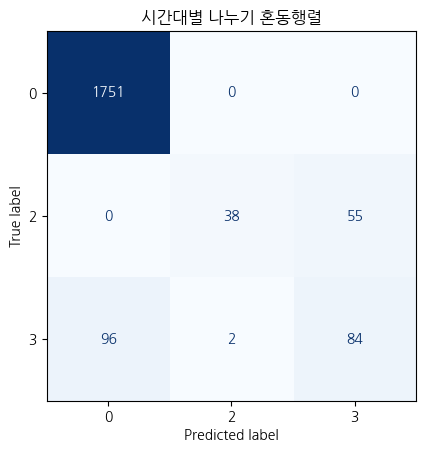

In [ ]:
# 혼동 행렬 확인
# Inspect the confusion matrix.
ConfusionMatrixDisplay.from_predictions(
    y_test_time,
    y_pred_time,
    cmap="Blues",
    colorbar=False
)

plt.title("시간대별 나누기 혼동행렬 (Chronological Split Confusion Matrix)")
plt.show()

### **두 실험 결과 비교**

---

### **Comparison of Two Experiment Results**

In [ ]:
results = pd.DataFrame({
    "Split": [
        "Random Split",
        "Chronological Split"
    ],
    "Accuracy": [
        rand_acc,
        time_acc
    ],
    "Macro F1": [
        rand_f1,
        time_f1
    ]
})

results

,Split,Accuracy,Macro F1
0,Random Split,0.997038,0.990284
1,Chronological Split,0.924482,0.689371


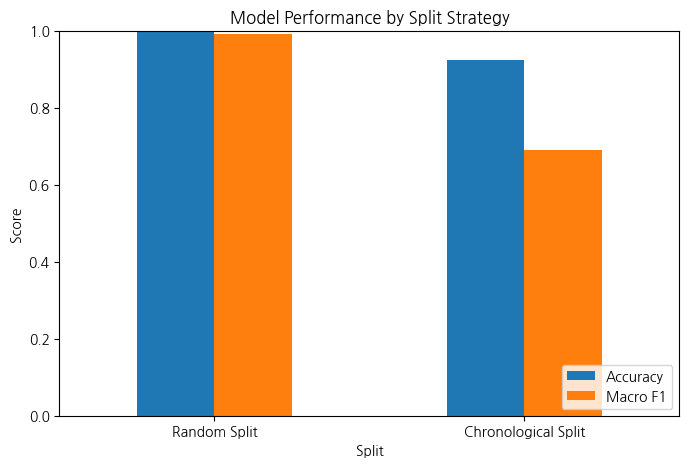

In [ ]:
# 결과 시각
# Visualize the results.
results.set_index("Split").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance by Split Strategy")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## 📌 결과 및 시사점

본 프로젝트에서는 동일한 Random Forest 모델과 동일한 센서 변수를 사용하고,
데이터 분할 방식만 **Random Split**과 **Chronological Split**으로 달리하여 성능을 비교하였다.

### 1. 데이터 분할 방식에 따라 평가 결과가 크게 달라짐

| Split Method | Accuracy | Macro F1 |
|---|---:|---:|
| Random Split | 0.997 | 0.990 |
| Chronological Split | 0.924 | 0.689 |

Random Split에서는 Accuracy와 Macro F1 모두 약 0.99로 매우 높은 성능을 보였으나,
시간 순서를 보존한 Chronological Split에서는 Accuracy가 약 0.92,
Macro F1은 약 0.69까지 감소하였다.

센서 데이터는 시간적으로 인접한 관측치끼리 유사한 값을 가질 가능성이 높다.
따라서 Random Split을 사용할 경우 서로 유사한 시점의 데이터가
train과 test에 동시에 포함되면서 실제 미래 시점에 대한 일반화 성능보다
낙관적인 평가 결과가 나타날 수 있다.

### 2. Accuracy만으로는 모델의 실제 성능을 충분히 설명하기 어려움

전체 데이터에서 `Room_Occupancy_Count = 0`이 약 81%를 차지하는
불균형한 클래스 구조를 가지고 있다.

Random Split의 Dummy Classifier 역시 가장 빈도가 높은 클래스만 예측했음에도
Accuracy가 약 0.81을 기록하였다.

따라서 본 데이터에서는 단순 Accuracy보다
각 클래스를 동일한 비중으로 평가하는 **Macro F1**을 함께 확인하는 것이 중요했다.

특히 Chronological Split에서 Accuracy는 0.924로 비교적 높게 유지되었지만,
Macro F1은 0.689로 크게 낮아졌다.
이는 전체 정확도만 보면 드러나지 않는 소수 클래스 예측 성능 저하가 존재함을 보여준다.

### 3. 미래 데이터에서는 재실 인원이 있는 상태를 구분하는 능력이 크게 감소함

Chronological Split의 클래스별 결과를 보면,

- Class 0: Recall 1.00
- Class 2: Recall 0.41
- Class 3: Recall 0.46

으로, 빈 강의실(Class 0)은 매우 잘 판별했지만
재실 인원이 존재하는 Class 2와 Class 3에 대해서는 성능이 크게 감소하였다.

혼동행렬에서도 Class 2의 93건 중 55건이 Class 3으로,
Class 3의 182건 중 96건이 Class 0으로 잘못 분류되었다.

따라서 센서 기반 재실 인원 예측 모델을 실제 운영 환경에 적용하려면
단순한 전체 정확도뿐 아니라 **각 occupancy class에 대한 재현율과 시간 변화에 따른
센서 패턴의 안정성**을 함께 고려해야 한다.

### 4. Chronological Split 결과 해석 시 주의점

Chronological Split의 test 구간에는 `Room_Occupancy_Count = 1`인 관측치가 존재하지 않았다.
따라서 Random Split의 Macro F1은 4개 클래스에 대한 평가인 반면,
Chronological Split의 Macro F1은 실제 test에 존재하는 클래스 구성이 다르다는 한계가 있다.

또한 Chronological test set은 전체 데이터의 마지막 20%라는 하나의 시간 구간만을 사용하므로,
이번 성능 차이를 전적으로 Random Split의 데이터 누수 효과라고 단정할 수는 없다.
시간에 따른 **데이터 분포 변화(temporal distribution shift)** 와
test 구간의 클래스 구성 차이 역시 성능 감소에 영향을 미쳤을 가능성이 있다.

### **Conclusion**

이번 분석에서는 동일한 센서 변수와 Random Forest 모델을 사용하더라도
Random Split과 Chronological Split에서 모델 성능이 크게 달라질 수 있음을 확인하였다.

특히 Chronological Split에서는 일부 occupancy class의 예측 성능이 크게 감소하였으며,
test 기간에는 `Room_Occupancy_Count = 1`인 관측치가 존재하지 않는 등
시간 구간별 클래스 분포에도 차이가 있었다.

이는 현재 데이터의 관측 기간만으로는 시간 변화에 따른 모든 재실 상태를
충분히 평가하기 어렵다는 한계를 보여준다.

따라서 향후에는 더 긴 기간 동안 데이터를 수집하여
다양한 시간대와 날짜에서 각 occupancy class가 충분히 관측되도록 하고,
그 데이터를 기반으로 모델의 시간적 일반화 성능을 다시 평가할 필요가 있겠다.

---

## 📌 Results and Implications

In this project, the same Random Forest model and the same sensor variables were used,
and performance was compared by varying only the data splitting method between **Random Split** and **Chronological Split**.

### 1. Evaluation Results Vary Significantly Depending on the Data Splitting Method

| Split Method | Accuracy | Macro F1 |
|---|---:|---:|
| Random Split | 0.997 | 0.990 |
| Chronological Split | 0.924 | 0.689 |

For Random Split, both Accuracy and Macro F1 showed very high performance, around 0.99,
whereas in Chronological Split, which preserves temporal order, Accuracy was about 0.92,
and Macro F1 decreased to approximately 0.69.

Sensor data is likely to have similar values for temporally adjacent observations.
Therefore, when using Random Split, data from similar time points
can be included in both train and test sets, leading to a more optimistic evaluation of generalization performance
than for actual future time points.

### 2. Accuracy Alone is Insufficient to Fully Explain the Model's True Performance

In the entire dataset, `Room_Occupancy_Count = 0` accounts for approximately 81%,
indicating an imbalanced class structure.

Even the Dummy Classifier for Random Split, which only predicted the most frequent class,
recorded an Accuracy of approximately 0.81.

Therefore, for this data, rather than simple Accuracy,
it was important to also check **Macro F1**, which evaluates each class with equal weight.

Particularly in Chronological Split, Accuracy remained relatively high at 0.924,
but Macro F1 significantly decreased to 0.689.
This shows that there is a degradation in the prediction performance of minority classes, which is not apparent when only looking at overall accuracy.

### 3. Ability to Distinguish Occupied States Significantly Decreases with Future Data

Looking at the class-wise results of Chronological Split,

- Class 0: Recall 1.00
- Class 2: Recall 0.41
- Class 3: Recall 0.46

Thus, empty classrooms (Class 0) were very well identified,
but performance significantly decreased for Class 2 and Class 3, where occupancy was present.

In the confusion matrix, 55 out of 93 instances of Class 2 were misclassified as Class 3,
and 96 out of 182 instances of Class 3 were misclassified as Class 0.

Therefore, to apply sensor-based occupancy prediction models in real operating environments,
not only simple overall accuracy but also **recall for each occupancy class and the stability of sensor patterns** with respect to temporal changes must be considered.

### 4. Caveats in Interpreting Chronological Split Results

In the test segment of Chronological Split, there were no observations with `Room_Occupancy_Count = 1`.
Therefore, while Random Split's Macro F1 is an evaluation for 4 classes,
Chronological Split's Macro F1 has the limitation that the actual class composition in the test set is different.

Furthermore, since the Chronological test set uses only one time segment, the last 20% of the entire data,
this performance difference cannot be entirely attributed to data leakage effects of Random Split.
Temporal distribution shift and
differences in the class composition of the test segment may also have contributed to the performance decrease.

### **Conclusion**

In this analysis, even when using the same sensor variables and Random Forest model,
it was confirmed that model performance can vary significantly between Random Split and Chronological Split.

Particularly in Chronological Split, the prediction performance of some occupancy classes significantly decreased,
and during the test period, there were no observations with `Room_Occupancy_Count = 1`,
indicating differences in class distribution across time segments.

This shows a limitation that the current data's observation period alone is insufficient to evaluate all occupancy states due to temporal changes
fully.

Therefore, in the future, it would be necessary to collect data over a longer period
to ensure that each occupancy class is sufficiently observed across various times of day and dates,
and then re-evaluate the model's temporal generalization performance based on that data.